## Primetrade.ai Assignment

In [1]:
import pandas as pd

# 1. Load both datasets
df_trader = pd.read_csv("historical_data (1).csv")
df_sentiment = pd.read_csv("fear_greed_index.csv")

# 2. Date Conversion for Merging
# Converting 'Timestamp IST' to standard YYYY-MM-DD string format
df_trader['Date'] = pd.to_datetime(df_trader['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
df_sentiment['Date'] = pd.to_datetime(df_sentiment['date']).dt.strftime('%Y-%m-%d')

# 3. Merge datasets on 'Date' using Inner Join
df_merged = pd.merge(df_trader, df_sentiment, on='Date', how='inner')

# 4. Calculate Win Rate by Sentiment Classification
# Filtering out 0 PnL trades to get clear Wins vs Losses
trades_with_pnl = df_merged[df_merged['Closed PnL'] != 0].copy()
trades_with_pnl['Win'] = trades_with_pnl['Closed PnL'] > 0
win_rate = trades_with_pnl.groupby('classification')['Win'].mean().reset_index()
win_rate.rename(columns={'Win': 'Win Rate (%)'}, inplace=True)
win_rate['Win Rate (%)'] = (win_rate['Win Rate (%)'] * 100).round(2)

# 5. Calculate Average Closed PnL by Sentiment
pnl_stats = df_merged.groupby('classification')['Closed PnL'].mean().reset_index()
pnl_stats.rename(columns={'Closed PnL': 'Avg Profit/Loss ($)'}, inplace=True)

# Print Results
print("--- Win Rate by Market Sentiment ---")
print(win_rate)
print("\n--- Average PnL by Market Sentiment ---")
print(pnl_stats)

--- Win Rate by Market Sentiment ---
  classification  Win Rate (%)
0   Extreme Fear         76.22
1  Extreme Greed         89.17
2           Fear         87.29
3          Greed         76.89
4        Neutral         82.39

--- Average PnL by Market Sentiment ---
  classification  Avg Profit/Loss ($)
0   Extreme Fear            34.537862
1  Extreme Greed            67.892861
2           Fear            54.290400
3          Greed            42.743559
4        Neutral            34.307718


C:\Users\hp\AppData\Local\Temp\ipykernel_816\2047315710.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='classification', y='Win Rate (%)', data=win_rate, palette='Blues_d')


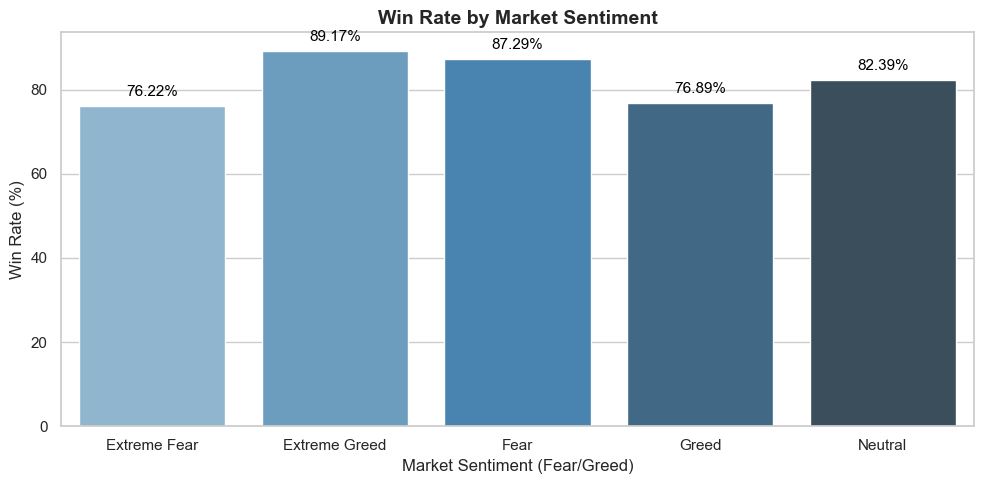

C:\Users\hp\AppData\Local\Temp\ipykernel_816\2047315710.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='classification', y='Avg Profit/Loss ($)', data=pnl_stats, palette='Greens_d')


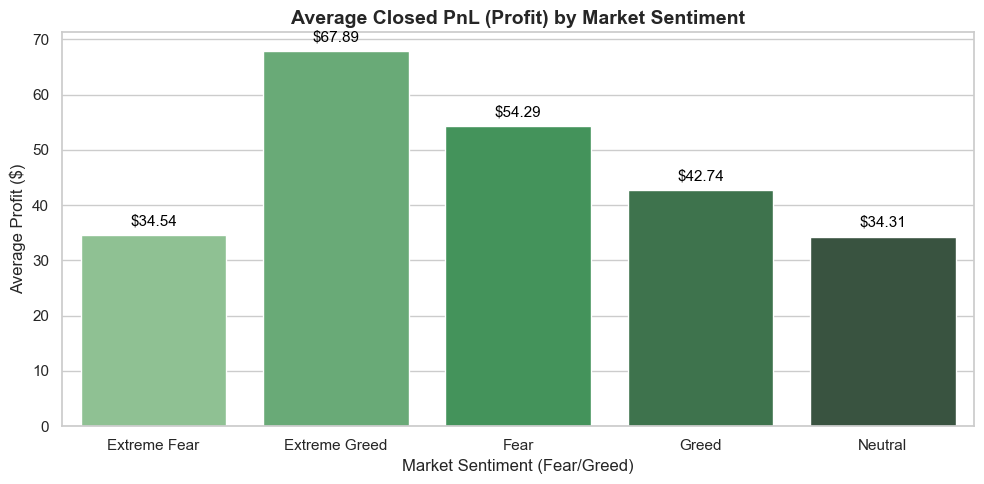

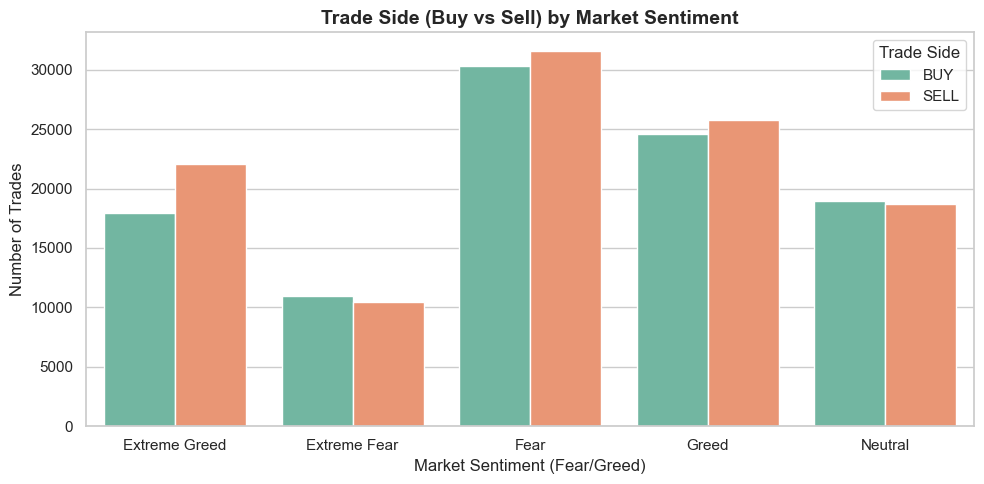

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Charts ka style set karna
sns.set_theme(style="whitegrid")

# ==========================================
# Chart 1: Win Rate by Market Sentiment
# ==========================================
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='classification', y='Win Rate (%)', data=win_rate, palette='Blues_d')

# Bars ke upar percentage values likhne ke liye
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Win Rate by Market Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment (Fear/Greed)', fontsize=12)
plt.ylabel('Win Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# Chart 2: Average Profit/Loss by Sentiment
# ==========================================
plt.figure(figsize=(10, 5))
ax2 = sns.barplot(x='classification', y='Avg Profit/Loss ($)', data=pnl_stats, palette='Greens_d')

# Bars ke upar amount likhne ke liye
for p in ax2.patches:
    ax2.annotate(f'${round(p.get_height(), 2)}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                 textcoords='offset points')

plt.title('Average Closed PnL (Profit) by Market Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment (Fear/Greed)', fontsize=12)
plt.ylabel('Average Profit ($)', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# Chart 3: Buy vs Sell (Long vs Short) Volume
# ==========================================
plt.figure(figsize=(10, 5))
sns.countplot(x='classification', hue='Side', data=df_merged, palette='Set2')

plt.title('Trade Side (Buy vs Sell) by Market Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment (Fear/Greed)', fontsize=12)
plt.ylabel('Number of Trades', fontsize=12)
plt.legend(title='Trade Side')
plt.tight_layout()
plt.show()